# Week 1 – Monthly Dataset Aggregation

The goal of Week 1 is to combine all monthly MLS files into two analysis-ready datasets: one for sold transactions and one for listing data. The handbook requires combining monthly files, filtering to Residential records where possible, saving new CSVs, and documenting row counts before and after filtering.

In [371]:
# Imports 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# 1. Load Data

sold = pd.read_csv("combined_sold.csv")
listed = pd.read_csv("combined_listings.csv")

agent_lookup = listed[
    [
        "ListingKey",
        "ListAgentFullName"
    ]
].drop_duplicates(subset=["ListingKey"])

sold = sold.merge(
    agent_lookup,
    on="ListingKey",
    how="left"
)

print(sold.columns)
print(sold["ListAgentFullName"].notna().sum())

# 2. Dataset Shapes

print("SOLD SHAPE:")
print(sold.shape)

print("\nLISTED SHAPE:")
print(listed.shape)


# 3. Review Columns

print("\nSOLD COLUMNS:")
print(sold.columns)

print("\nLISTED COLUMNS:")
print(listed.columns)


# 4. Preview Data

print("\nSOLD HEAD:")
print(sold.head())

print("\nLISTED HEAD:")
print(listed.head())


# 5. Check Missing Values

print("\nSOLD MISSING VALUES:")
print(sold.isnull().sum())

print("\nLISTED MISSING VALUES:")
print(listed.isnull().sum())


# 6. Property Type Distribution

print("\nPROPERTY TYPE DISTRIBUTION:")
print(listed["PropertyType"].value_counts(dropna=False))


# 7. Create Residential Dataset

sold_residential = sold[
    sold["PropertyType"] == "Residential"
].copy()

listed_residential = listed[
    listed["PropertyType"] == "Residential"
].copy()

residential = pd.concat(
    [sold_residential, listed_residential],
    ignore_index=True,
    sort=False
)

print("\nORIGINAL SOLD ROWS:")
print(len(sold))

print("\nORIGINAL LISTED ROWS:")
print(len(listed))

print("\nRESIDENTIAL ROWS:")
print(len(residential))

print("\nRESIDENTIAL COLUMNS:")
print(residential.columns)


# 8. Verify Residential Filter

print("\nRESIDENTIAL PROPERTY TYPE CHECK:")
print(residential["PropertyType"].value_counts(dropna=False))

print("\nKEY COMPETITIVE ANALYSIS FIELDS:")
print("ClosePrice:", "ClosePrice" in residential.columns)
print("ListAgentFullName:", "ListAgentFullName" in residential.columns)
print("ListOfficeName:", "ListOfficeName" in residential.columns)
print("Latitude:", "Latitude" in residential.columns)
print("Longitude:", "Longitude" in residential.columns)


# 9. Save Residential Dataset

residential.to_csv(
    "residential_listings.csv",
    index=False
)

print("\nResidential dataset saved successfully.")

Index(['ListingKey', 'City', 'PostalCode', 'PropertyType', 'PropertySubType',
       'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'ListPrice', 'OriginalListPrice', 'ClosePrice', 'CloseDate',
       'ListingContractDate', 'PurchaseContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BedroomsTotal',
       'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddress',
       'ListAgentFullName'],
      dtype='object')
562042
SOLD SHAPE:
(606713, 23)

LISTED SHAPE:
(660548, 22)

SOLD COLUMNS:
Index(['ListingKey', 'City', 'PostalCode', 'PropertyType', 'PropertySubType',
       'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'ListPrice', 'OriginalListPrice', 'ClosePrice', 'CloseDate',
       'ListingContractDate', 'PurchaseContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BedroomsTotal',
       'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddress',
       'ListAgentFullName'],
     

In [372]:
print("ClosePrice:", "ClosePrice" in residential.columns)
print("ListAgentFullName:", "ListAgentFullName" in residential.columns)
print("ListOfficeName:", "ListOfficeName" in residential.columns)
print("Latitude:", "Latitude" in residential.columns)
print("Longitude:", "Longitude" in residential.columns)

ClosePrice: True
ListAgentFullName: True
ListOfficeName: True
Latitude: True
Longitude: True


The sold dataset contains 606,706 observations and 12 variables. The listed dataset contains 662,171 observations and 20 variables.

Both datasets were successfully loaded and reviewed. Key variables needed for future analysis, including OriginalListPrice, PurchaseContractDate, PropertyType, CountyOrParish, and geographic coordinates, are present.

Property type analysis showed that Residential properties account for the majority of listings. Because the project focuses on residential housing market trends, a separate residential dataset was created and will be used for subsequent feature engineering, market analysis, and outlier detection tasks.

# Weeks 2–3 - Dataset Structuring and Validation

The goal of Weeks 2–3 is to inspect the sold and residential listing datasets, validate the structure of the data, check missing values, review key numeric fields, and enrich the data with mortgage rate information from FRED.

In [373]:
# 1. Dataset Structure

print("SOLD SHAPE:")
print(sold.shape)

print("\nRESIDENTIAL LISTINGS SHAPE:")
print(residential.shape)

print("\nSOLD COLUMNS:")
print(sold.columns)

print("\nRESIDENTIAL LISTINGS COLUMNS:")
print(residential.columns)

print("\nSOLD DATA TYPES:")
print(sold.dtypes)

print("\nRESIDENTIAL LISTINGS DATA TYPES:")
print(residential.dtypes)

print("\nSOLD HEAD:")
print(sold.head())

print("\nRESIDENTIAL LISTINGS HEAD:")
print(residential.head())

SOLD SHAPE:
(606713, 23)

RESIDENTIAL LISTINGS SHAPE:
(839073, 24)

SOLD COLUMNS:
Index(['ListingKey', 'City', 'PostalCode', 'PropertyType', 'PropertySubType',
       'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'ListPrice', 'OriginalListPrice', 'ClosePrice', 'CloseDate',
       'ListingContractDate', 'PurchaseContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BedroomsTotal',
       'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddress',
       'ListAgentFullName'],
      dtype='object')

RESIDENTIAL LISTINGS COLUMNS:
Index(['ListingKey', 'City', 'PostalCode', 'PropertyType', 'PropertySubType',
       'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'ListPrice', 'OriginalListPrice', 'ClosePrice', 'CloseDate',
       'ListingContractDate', 'PurchaseContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BedroomsTotal',
       'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddres

The sold dataset represents closed transactions, while the residential listings dataset represents residential properties that entered the market. Reviewing shapes, column names, data types, and sample rows confirms that the datasets are structured properly before analysis.

In [374]:
# 2. Property Type Validation

print("RESIDENTIAL PROPERTY TYPE CHECK:")
print(residential["PropertyType"].value_counts(dropna=False))

RESIDENTIAL PROPERTY TYPE CHECK:
PropertyType
Residential    839073
Name: count, dtype: int64


The residential dataset contains only Residential properties, confirming that the property type filter was applied correctly.

In [375]:
# 3. Separate Market Analysis Fields from Metadata Fields

sold_market_fields = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "BedroomsTotal",
    "CloseDate",
    "ListingContractDate",
    "PurchaseContractDate",
    "City",
    "PostalCode",
    "PropertyType"
]

sold_market_fields = [
    col for col in sold_market_fields
    if col in sold.columns
]

sold_metadata_fields = [
    col for col in sold.columns
    if col not in sold_market_fields
]

residential_market_fields = [
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "ListingContractDate",
    "PurchaseContractDate",
    "PropertyType",
    "City",
    "PostalCode",
    "CountyOrParish",
    "Latitude",
    "Longitude"
]

residential_market_fields = [
    col for col in residential_market_fields
    if col in residential.columns
]

residential_metadata_fields = [
    col for col in residential.columns
    if col not in residential_market_fields
]

print("SOLD MARKET ANALYSIS FIELDS:")
print(sold_market_fields)

print("\nSOLD METADATA FIELDS:")
print(sold_metadata_fields)

print("\nRESIDENTIAL MARKET ANALYSIS FIELDS:")
print(residential_market_fields)

print("\nRESIDENTIAL METADATA FIELDS:")
print(residential_metadata_fields)

SOLD MARKET ANALYSIS FIELDS:
['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'BedroomsTotal', 'CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'City', 'PostalCode', 'PropertyType']

SOLD METADATA FIELDS:
['ListingKey', 'PropertySubType', 'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName', 'ContractStatusChangeDate', 'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddress', 'ListAgentFullName']

RESIDENTIAL MARKET ANALYSIS FIELDS:
['ListPrice', 'OriginalListPrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'ListingContractDate', 'PurchaseContractDate', 'PropertyType', 'City', 'PostalCode', 'CountyOrParish', 'Latitude', 'Longitude']

RESIDENTIAL METADATA FIELDS:
['ListingKey', 'PropertySubType', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName', 'ClosePrice', 'CloseDate', 'ContractStatusChangeDate', 'UnparsedAddress', 'ListAgentFullName', 'BuyerAgentFullName']


Market analysis fields are variables used directly for pricing, timing, location, and property characteristics. Metadata fields, such as identifiers and office names, are useful for joining records or reference but are not the primary focus of market analysis.

In [376]:
# 4. Missing Value Report

sold_missing = pd.DataFrame({
    "missing_count": sold.isnull().sum(),
    "missing_percent": (sold.isnull().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

residential_missing = pd.DataFrame({
    "missing_count": residential.isnull().sum(),
    "missing_percent": (residential.isnull().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

print("SOLD MISSING VALUE REPORT:")
print(sold_missing)

print("\nRESIDENTIAL LISTINGS MISSING VALUE REPORT:")
print(residential_missing)

SOLD MISSING VALUE REPORT:
                          missing_count  missing_percent
Latitude                          70592            11.64
Longitude                         70087            11.55
MLSAreaMajor                      67928            11.20
PropertySubType                   47161             7.77
ListAgentFullName                 44671             7.36
LivingArea                        43693             7.20
BedroomsTotal                     41035             6.76
BathroomsTotalInteger             28294             4.66
PurchaseContractDate              12506             2.06
BuyerOfficeName                    6292             1.04
OriginalListPrice                  1896             0.31
UnparsedAddress                    1003             0.17
ListPrice                           965             0.16
ContractStatusChangeDate            690             0.11
City                                389             0.06
PostalCode                          170             0.03
List

Missing values were calculated as counts and percentages for each column. This helps identify which fields are complete enough for analysis and which may need additional handling.

In [377]:
# 5. Flag Columns Above 90% Missing

sold_high_missing = sold_missing[sold_missing["missing_percent"] > 90]
residential_high_missing = residential_missing[
    residential_missing["missing_percent"] > 90
]

print("SOLD COLUMNS ABOVE 90% MISSING:")
print(sold_high_missing)

print("\nRESIDENTIAL COLUMNS ABOVE 90% MISSING:")
print(residential_high_missing)

SOLD COLUMNS ABOVE 90% MISSING:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

RESIDENTIAL COLUMNS ABOVE 90% MISSING:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


Columns with more than 90% missing values were flagged for review. These fields may be dropped later if they are not essential, while core market fields should be retained when possible.

In [378]:
# 6. Convert Date Fields

date_fields = [
    "CloseDate",
    "ListingContractDate",
    "PurchaseContractDate"
]

for col in date_fields:
    if col in sold.columns:
        sold[col] = pd.to_datetime(sold[col], errors="coerce")

for col in [
    "ListingContractDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate"
]:
    if col in residential.columns:
        residential[col] = pd.to_datetime(residential[col], errors="coerce")

print("SOLD DATE FIELD TYPES:")
print(sold[[col for col in date_fields if col in sold.columns]].dtypes)

print("\nRESIDENTIAL DATE FIELD TYPES:")
residential_date_cols = [
    col for col in [
        "ListingContractDate",
        "PurchaseContractDate",
        "ContractStatusChangeDate"
    ]
    if col in residential.columns
]
print(residential[residential_date_cols].dtypes)

SOLD DATE FIELD TYPES:
CloseDate               datetime64[ns]
ListingContractDate     datetime64[ns]
PurchaseContractDate    datetime64[ns]
dtype: object

RESIDENTIAL DATE FIELD TYPES:
ListingContractDate         datetime64[ns]
PurchaseContractDate        datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object


Date fields were converted to datetime format so that time-based metrics and validation checks can be calculated correctly.

In [379]:
# Clean duplicate ListingContractDate columns

if "ListingContractDate_x" in sold.columns:
    sold["ListingContractDate"] = sold["ListingContractDate_x"]
elif "ListingContractDate_y" in sold.columns:
    sold["ListingContractDate"] = sold["ListingContractDate_y"]

sold["ListingContractDate"] = pd.to_datetime(
    sold["ListingContractDate"],
    errors="coerce"
)

sold["PurchaseContractDate"] = pd.to_datetime(
    sold["PurchaseContractDate"],
    errors="coerce"
)

print(sold[[
    "ListingContractDate",
    "PurchaseContractDate"
]].head())

  ListingContractDate PurchaseContractDate
0          2023-11-16           2023-11-16
1          2024-01-30           2024-01-30
2          2024-01-29           2024-01-29
3          2023-11-15           2023-11-15
4          2023-11-17           2023-12-19


In [380]:
# 7. Create Days on Market

sold["DaysOnMarket"] = (
    sold["PurchaseContractDate"] - sold["ListingContractDate"]
).dt.days

print("DAYS ON MARKET SUMMARY:")
print(sold["DaysOnMarket"].describe())

print("\nDAYS ON MARKET PREVIEW:")
print(sold[[
    "ListingContractDate",
    "PurchaseContractDate",
    "DaysOnMarket"
]].head())

DAYS ON MARKET SUMMARY:
count    594119.000000
mean         50.983253
std          95.425206
min      -36407.000000
25%          11.000000
50%          28.000000
75%          63.000000
max       14657.000000
Name: DaysOnMarket, dtype: float64

DAYS ON MARKET PREVIEW:
  ListingContractDate PurchaseContractDate  DaysOnMarket
0          2023-11-16           2023-11-16           0.0
1          2024-01-30           2024-01-30           0.0
2          2024-01-29           2024-01-29           0.0
3          2023-11-15           2023-11-15           0.0
4          2023-11-17           2023-12-19          32.0


DaysOnMarket was calculated as the number of days between the listing contract date and the purchase contract date. This measures how long it took for a property to receive an accepted offer.

In [381]:
# 8. Numeric Distribution Summary

numeric_fields = [
    "ClosePrice",
    "LivingArea",
    "DaysOnMarket"
]

available_numeric_fields = [
    col for col in numeric_fields
    if col in sold.columns
]

numeric_summary = sold[available_numeric_fields].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

print("NUMERIC DISTRIBUTION SUMMARY:")
print(numeric_summary)

# 9. Numeric Distribution Checkpoints

for col in available_numeric_fields:
    print(f"\n{col} DISTRIBUTION CHECKPOINTS:")
    print("Minimum:", sold[col].min())
    print("1st percentile:", sold[col].quantile(0.01))
    print("Median:", sold[col].median())
    print("Mean:", sold[col].mean())
    print("99th percentile:", sold[col].quantile(0.99))
    print("Maximum:", sold[col].max())

NUMERIC DISTRIBUTION SUMMARY:
                 count           mean           std      min      1%      5%  \
ClosePrice    606705.0  820201.787159  1.625305e+06      0.0  1750.0  2687.2   
LivingArea    563020.0    3455.321788  1.211772e+06      0.0   480.0   731.0   
DaysOnMarket  594119.0      50.983253  9.542521e+01 -36407.0     0.0     3.0   

                  25%       50%        75%        95%         99%          max  
ClosePrice    45000.0  620000.0  1050000.0  2440000.0  4850000.00  748655000.0  
LivingArea     1180.0    1576.0     2147.0     3533.0     5471.81  909090909.0  
DaysOnMarket     11.0      28.0       63.0      167.0      340.00      14657.0  

ClosePrice DISTRIBUTION CHECKPOINTS:
Minimum: 0.0
1st percentile: 1750.0
Median: 620000.0
Mean: 820201.7871587016
99th percentile: 4850000.0
Maximum: 748655000.0

LivingArea DISTRIBUTION CHECKPOINTS:
Minimum: 0.0
1st percentile: 480.0
Median: 1576.0
Mean: 3455.3217877340066
99th percentile: 5471.8099999999395
Maximum: 9090

Numeric summaries were generated for ClosePrice, LivingArea, and DaysOnMarket. Percentiles help identify extreme values without immediately removing records.

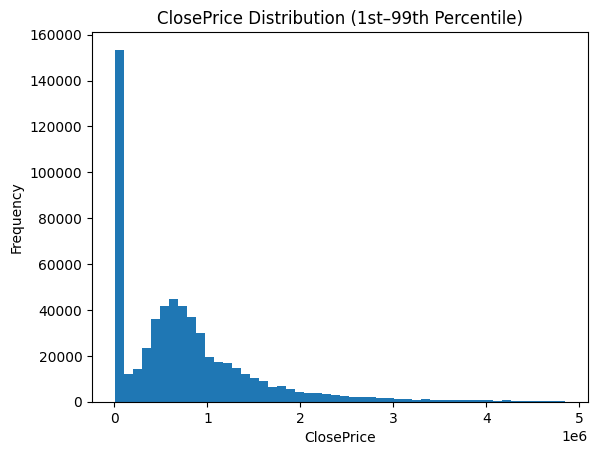

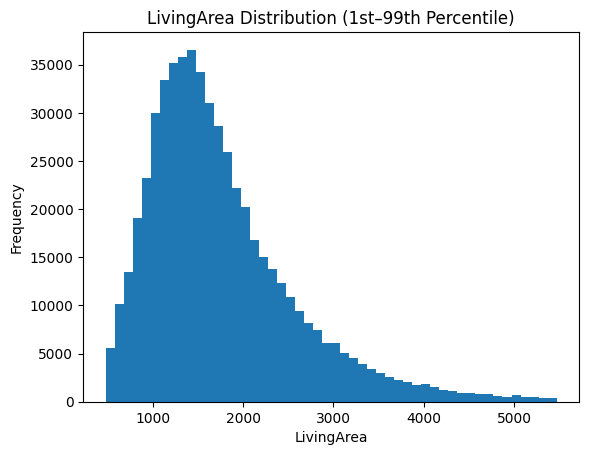

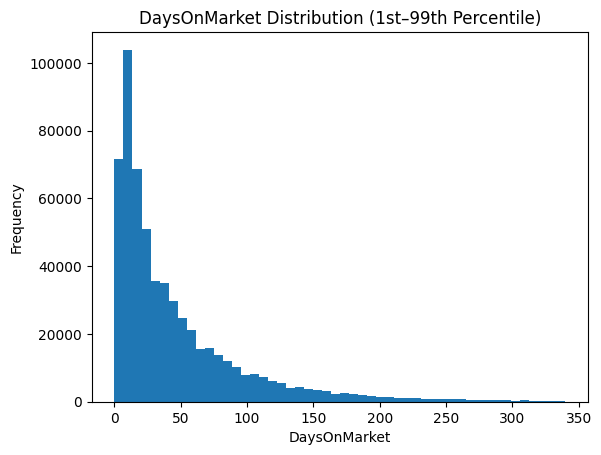

In [382]:
# 10. Numeric Distribution Visuals - Histograms

for col in available_numeric_fields:
    cleaned_col = sold[col].dropna()

    lower = cleaned_col.quantile(0.01)
    upper = cleaned_col.quantile(0.99)

    filtered_col = cleaned_col[
        (cleaned_col >= lower) &
        (cleaned_col <= upper)
    ]

    filtered_col.plot.hist(bins=50)

    plt.title(f"{col} Distribution (1st–99th Percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

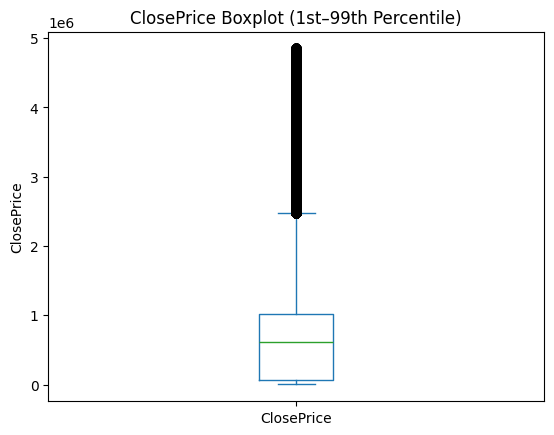

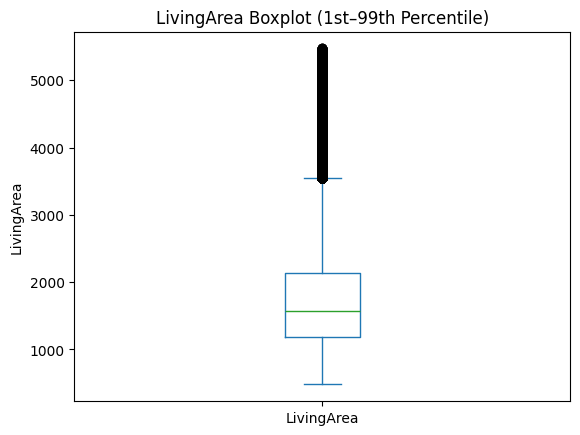

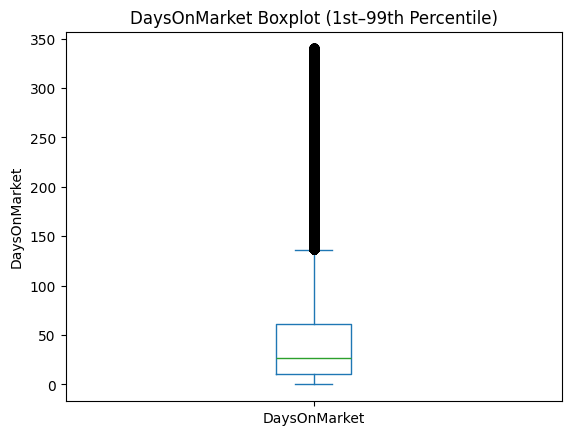

In [383]:
# 11. Numeric Distribution Visuals - Boxplots

for col in available_numeric_fields:
    cleaned_col = sold[col].dropna()

    lower = cleaned_col.quantile(0.01)
    upper = cleaned_col.quantile(0.99)

    filtered_col = cleaned_col[
        (cleaned_col >= lower) &
        (cleaned_col <= upper)
    ]

    filtered_col.plot.box()

    plt.title(f"{col} Boxplot (1st–99th Percentile)")
    plt.ylabel(col)

    plt.show()

Histograms and boxplots were generated for the required numeric fields. The 1st–99th percentile range was used only for visualization so extreme values do not distort the plots.

In [384]:
import pandas as pd

mortgage = pd.read_csv("MORTGAGE30US.csv")

print(mortgage.columns)
print(mortgage.head())

Index(['observation_date', 'MORTGAGE30US'], dtype='object')
  observation_date  MORTGAGE30US
0       1971-04-01          7.31
1       1971-05-01          7.43
2       1971-06-01          7.53
3       1971-07-01          7.60
4       1971-08-01          7.70


In [385]:
# 12. Mortgage Rate Enrichment with Downloaded FRED Data

import pandas as pd

# Load downloaded FRED mortgage rate data
mortgage = pd.read_csv("MORTGAGE30US.csv")

# Rename columns
mortgage.columns = ["date", "rate_30yr_fixed"]

# Convert date column
mortgage["date"] = pd.to_datetime(mortgage["date"], errors="coerce")

# Create year-month key
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

# Monthly mortgage rate dataset
mortgage_monthly = (
    mortgage
    .groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

# Create matching year-month keys
sold["year_month"] = pd.to_datetime(
    sold["CloseDate"],
    errors="coerce"
).dt.to_period("M")

listed["year_month"] = pd.to_datetime(
    listed["ListingContractDate"],
    errors="coerce"
).dt.to_period("M")

# Merge mortgage rates onto sold and listed datasets
sold_with_rates = sold.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

listed_with_rates = listed.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

# Validate merge
print("Unmatched sold rows:")
print(sold_with_rates["rate_30yr_fixed"].isnull().sum())

print("\nUnmatched listed rows:")
print(listed_with_rates["rate_30yr_fixed"].isnull().sum())

print("\nSold preview:")
print(sold_with_rates[["CloseDate", "year_month", "ClosePrice", "rate_30yr_fixed"]].head())

print("\nListed preview:")
print(listed_with_rates[["ListingContractDate", "year_month", "ListPrice", "rate_30yr_fixed"]].head())

Unmatched sold rows:
0

Unmatched listed rows:
0

Sold preview:
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-18    2024-01   5000000.0             6.64
1 2024-01-30    2024-01    858000.0             6.64
2 2024-01-29    2024-01   1890500.0             6.64
3 2024-01-02    2024-01   2100000.0             6.64
4 2024-01-22    2024-01   1950000.0             6.64

Listed preview:
  ListingContractDate year_month  ListPrice  rate_30yr_fixed
0          2024-01-27    2024-01   375000.0             6.64
1          2024-01-06    2024-01   759000.0             6.64
2          2024-01-11    2024-01   320000.0             6.64
3          2024-01-01    2024-01     2750.0             6.64
4          2024-01-01    2024-01     3599.0             6.64


In [386]:
# 13. Prepare Monthly Mortgage Rate Data

mortgage = pd.read_csv("MORTGAGE30US.csv")

print("ORIGINAL COLUMNS:")
print(mortgage.columns)

# Rename FRED columns
mortgage.columns = ["date", "rate_30yr_fixed"]

# Convert types
mortgage["date"] = pd.to_datetime(mortgage["date"])
mortgage["rate_30yr_fixed"] = pd.to_numeric(
    mortgage["rate_30yr_fixed"],
    errors="coerce"
)

# Create year-month key
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

# Monthly mortgage rate dataset
mortgage_monthly = (
    mortgage.groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

print("\nMONTHLY MORTGAGE RATE DATA:")
print(mortgage_monthly.head())

ORIGINAL COLUMNS:
Index(['observation_date', 'MORTGAGE30US'], dtype='object')

MONTHLY MORTGAGE RATE DATA:
  year_month  rate_30yr_fixed
0    1971-04             7.31
1    1971-05             7.43
2    1971-06             7.53
3    1971-07             7.60
4    1971-08             7.70


In [387]:
# 14. Merge Mortgage Rates Onto Sold and Residential Data

sold["year_month"] = sold["CloseDate"].dt.to_period("M")
residential["year_month"] = residential[
    "ListingContractDate"
].dt.to_period("M")

sold_with_rates = sold.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

residential_with_rates = residential.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

print("MISSING MORTGAGE RATES IN SOLD DATASET:")
print(sold_with_rates["rate_30yr_fixed"].isnull().sum())

print("\nMISSING MORTGAGE RATES IN RESIDENTIAL LISTINGS DATASET:")
print(residential_with_rates["rate_30yr_fixed"].isnull().sum())

MISSING MORTGAGE RATES IN SOLD DATASET:
0

MISSING MORTGAGE RATES IN RESIDENTIAL LISTINGS DATASET:
1


In [388]:
# 15. Preview Mortgage Rate Merge

print("SOLD WITH MORTGAGE RATES PREVIEW:")
print(sold_with_rates[[
    "CloseDate",
    "year_month",
    "ClosePrice",
    "rate_30yr_fixed"
]].head())

print("\nRESIDENTIAL LISTINGS WITH MORTGAGE RATES PREVIEW:")
print(residential_with_rates[[
    "ListingContractDate",
    "year_month",
    "ListPrice",
    "rate_30yr_fixed"
]].head())

SOLD WITH MORTGAGE RATES PREVIEW:
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-18    2024-01   5000000.0             6.64
1 2024-01-30    2024-01    858000.0             6.64
2 2024-01-29    2024-01   1890500.0             6.64
3 2024-01-02    2024-01   2100000.0             6.64
4 2024-01-22    2024-01   1950000.0             6.64

RESIDENTIAL LISTINGS WITH MORTGAGE RATES PREVIEW:
  ListingContractDate year_month  ListPrice  rate_30yr_fixed
0          2023-11-16    2023-11  5000000.0             7.44
1          2024-01-30    2024-01   858000.0             6.64
2          2024-01-29    2024-01  1890500.0             6.64
3          2023-11-15    2023-11  2100000.0             7.44
4          2023-11-17    2023-11  1950000.0             7.44


The national 30-year fixed mortgage rate from FRED was converted to monthly averages and merged onto both sold and residential listing datasets using a monthly date key. This allows future analysis to consider interest rate conditions alongside housing market activity.

In [389]:
# 16. Save Weeks 2–3 Outputs

sold.to_csv("week2_3_sold_validated.csv", index=False)
residential.to_csv("week2_3_residential_listings_validated.csv", index=False)

sold_with_rates.to_csv("sold_with_mortgage_rates.csv", index=False)
residential_with_rates.to_csv(
    "residential_listings_with_mortgage_rates.csv",
    index=False
)

print("Saved week2_3_sold_validated.csv")
print("Saved week2_3_residential_listings_validated.csv")
print("Saved sold_with_mortgage_rates.csv")
print("Saved residential_listings_with_mortgage_rates.csv")

Saved week2_3_sold_validated.csv
Saved week2_3_residential_listings_validated.csv
Saved sold_with_mortgage_rates.csv
Saved residential_listings_with_mortgage_rates.csv


### Suggested Intern Questions

1. **What is the Residential vs. other property type share?**  
The full listing dataset includes multiple property types, but Residential properties make up the largest share. A residential-only dataset was created for future analysis.

2. **What are the median and average close prices?**  
The median and average close prices were calculated from the sold dataset. If the mean is higher than the median, this suggests that high-priced homes are pulling the average upward.

3. **What does the Days on Market distribution look like?**  
DaysOnMarket was calculated using PurchaseContractDate minus ListingContractDate. The distribution helps show how quickly homes move from listing to accepted offer.

4. **What percentage of homes sold above vs. below list price?**  
This will be measured using ClosePrice and ListPrice in later feature engineering. It helps indicate market competitiveness.

5. **Are there any apparent date consistency issues?**  
Date fields were converted to datetime format so timeline issues can be checked in later cleaning steps.

6. **Which areas have the highest median prices?**  
Geographic analysis can be completed using City and CountyOrParish fields now that these variables are available.

For Weeks 2–3, the datasets were inspected, validated, and enriched. This section completed dataset structure checks, property type validation, missing value reports, numeric summaries, distribution visuals, DaysOnMarket creation, and FRED mortgage rate enrichment.

# Weeks 4–5 - Data Cleaning and Preparation

The goal of Weeks 4–5 is to clean the dataset, confirm data quality, create key market metrics, and prepare an analysis-ready dataset for later dashboard and modeling work.

### 1. Create Working Copy

In [390]:
cleaned_sold = sold.copy()

print("Rows before cleaning:", len(cleaned_sold))

Rows before cleaning: 606713


A copy of the sold dataset was created so the original dataset is not overwritten during cleaning.

### 2. Confirm Date Fields

In [391]:
cleaned_sold["CloseDate"] = pd.to_datetime(cleaned_sold["CloseDate"], errors="coerce")
cleaned_sold["ListingContractDate"] = pd.to_datetime(cleaned_sold["ListingContractDate"], errors="coerce")
cleaned_sold["PurchaseContractDate"] = pd.to_datetime(cleaned_sold["PurchaseContractDate"], errors="coerce")

print(cleaned_sold[["CloseDate", "ListingContractDate", "PurchaseContractDate"]].dtypes)

CloseDate               datetime64[ns]
ListingContractDate     datetime64[ns]
PurchaseContractDate    datetime64[ns]
dtype: object


Date fields were converted to datetime format so transaction timelines can be checked and time-based metrics can be calculated correctly.

### 3. Create Price Per Square Foot

In [392]:
cleaned_sold["PricePerSqft"] = cleaned_sold["ClosePrice"] / cleaned_sold["LivingArea"]

print(cleaned_sold["PricePerSqft"].describe())

count    5.630120e+05
mean              inf
std               NaN
min      0.000000e+00
25%      6.770833e+01
50%      4.094579e+02
75%      6.396580e+02
max               inf
Name: PricePerSqft, dtype: float64


Price per square foot standardizes property values and allows homes of different sizes to be compared more fairly.

### 4. Create Sale to List Ratio

In [393]:
cleaned_sold["SaleToListRatio"] = cleaned_sold["ClosePrice"] / cleaned_sold["ListPrice"]

print(cleaned_sold["SaleToListRatio"].describe())

count    6.057390e+05
mean              inf
std               NaN
min      0.000000e+00
25%      9.759760e-01
50%      1.000000e+00
75%      1.007701e+00
max               inf
Name: SaleToListRatio, dtype: float64


Sale to List Ratio measures how close the final sale price is to the listing price. Values above 1 indicate homes sold above asking price.

### 5. Create Close to Original List Ratio

In [394]:
cleaned_sold["CloseToOriginalListRatio"] = (
    cleaned_sold["ClosePrice"] / cleaned_sold["OriginalListPrice"]
)

print(cleaned_sold["CloseToOriginalListRatio"].describe())

count    6.048090e+05
mean              inf
std               NaN
min      0.000000e+00
25%      9.446009e-01
50%      9.966667e-01
75%      1.005670e+00
max               inf
Name: CloseToOriginalListRatio, dtype: float64


Close to Original List Ratio compares the final sale price to the original list price and captures price changes from the beginning of the listing history.

### 6. Create Days on Market

In [395]:
cleaned_sold["DaysOnMarket"] = (
    cleaned_sold["PurchaseContractDate"] - cleaned_sold["ListingContractDate"]
).dt.days

print(cleaned_sold["DaysOnMarket"].describe())

count    594119.000000
mean         50.983253
std          95.425206
min      -36407.000000
25%          11.000000
50%          28.000000
75%          63.000000
max       14657.000000
Name: DaysOnMarket, dtype: float64


Days on Market measures the number of days between the listing date and the accepted contract date.

### 7. Date Consistency Flags

In [396]:
cleaned_sold["listing_after_purchase_flag"] = (
    cleaned_sold["ListingContractDate"] > cleaned_sold["PurchaseContractDate"]
)

cleaned_sold["purchase_after_close_flag"] = (
    cleaned_sold["PurchaseContractDate"] > cleaned_sold["CloseDate"]
)

cleaned_sold["listing_after_close_flag"] = (
    cleaned_sold["ListingContractDate"] > cleaned_sold["CloseDate"]
)

print("Listing after purchase:", cleaned_sold["listing_after_purchase_flag"].sum())
print("Purchase after close:", cleaned_sold["purchase_after_close_flag"].sum())
print("Listing after close:", cleaned_sold["listing_after_close_flag"].sum())

Listing after purchase: 419
Purchase after close: 234
Listing after close: 141


Date consistency flags identify records with impossible or suspicious transaction timelines, such as a purchase contract date occurring after the closing date.

### 8. Remove Clearly Invalid Records

In [397]:
before_invalid_filter = len(cleaned_sold)

cleaned_sold = cleaned_sold[
    (cleaned_sold["ClosePrice"] > 0) &
    (cleaned_sold["ListPrice"] > 0) &
    (cleaned_sold["OriginalListPrice"] > 0) &
    (cleaned_sold["LivingArea"] > 0) &
    (cleaned_sold["DaysOnMarket"] >= 0) &
    (cleaned_sold["listing_after_purchase_flag"] == False) &
    (cleaned_sold["purchase_after_close_flag"] == False) &
    (cleaned_sold["listing_after_close_flag"] == False)
].copy()

print("Rows before invalid-record filter:", before_invalid_filter)
print("Rows after invalid-record filter:", len(cleaned_sold))
print("Rows removed:", before_invalid_filter - len(cleaned_sold))

Rows before invalid-record filter: 606713
Rows after invalid-record filter: 549340
Rows removed: 57373


Records with impossible values, such as non-positive prices, non-positive living area, negative Days on Market, or invalid date sequences, were removed from the cleaned dataset.

### 9. Clean Extreme Ratio Values

In [398]:
before_ratio_filter = len(cleaned_sold)

cleaned_sold = cleaned_sold[
    (cleaned_sold["SaleToListRatio"] >= 0.5) &
    (cleaned_sold["SaleToListRatio"] <= 1.5) &
    (cleaned_sold["CloseToOriginalListRatio"] >= 0.5) &
    (cleaned_sold["CloseToOriginalListRatio"] <= 1.5)
].copy()

print("Rows before ratio filter:", before_ratio_filter)
print("Rows after ratio filter:", len(cleaned_sold))
print("Rows removed:", before_ratio_filter - len(cleaned_sold))

Rows before ratio filter: 549340
Rows after ratio filter: 546667
Rows removed: 2673


Extreme ratio values were removed because they may represent data entry issues or unusual transactions that could distort market analysis.

### 10. Geographic Data Quality Check

In [399]:
print("Missing Latitude:", residential["Latitude"].isnull().sum())
print("Missing Longitude:", residential["Longitude"].isnull().sum())
print("Latitude = 0:", (residential["Latitude"] == 0).sum())
print("Longitude = 0:", (residential["Longitude"] == 0).sum())
print("Longitude > 0:", (residential["Longitude"] > 0).sum())

Missing Latitude: 102023
Missing Longitude: 102023
Latitude = 0: 80
Longitude = 0: 80
Longitude > 0: 92


Latitude and longitude were checked for missing or invalid values to support future mapping and geographic analysis.

### 11. Final Row Count

In [400]:
print("Rows before cleaning:", len(sold))
print("Rows after cleaning:", len(cleaned_sold))
print("Total rows removed:", len(sold) - len(cleaned_sold))

Rows before cleaning: 606713
Rows after cleaning: 546667
Total rows removed: 60046


The before-and-after row count documents how much of the dataset was removed during cleaning.

### 12. Save Cleaned Dataset

In [401]:
cleaned_sold.to_csv("cleaned_sold_week4_5.csv", index=False)

print("Saved cleaned_sold_week4_5.csv")

Saved cleaned_sold_week4_5.csv


The cleaned dataset was saved so future analysis can use a consistent, analysis-ready file.

### 13. Weeks 4–5 Summary

For Weeks 4–5, the sold dataset was cleaned and prepared for analysis. Key market metrics were created, including PricePerSqft, SaleToListRatio, CloseToOriginalListRatio, and DaysOnMarket.

Date consistency checks were added to identify invalid transaction timelines. Clearly invalid records and extreme ratio values were removed, while geographic data quality was checked using latitude and longitude from the residential listings dataset.

The final cleaned dataset was saved as `cleaned_sold_week4_5.csv`.

# Week 6 - Feature Engineering and Market Metrics

The goal of Week 6 is to create key housing market metrics that will support Tableau dashboards and market analysis.

### 1. Create Working Dataset

In [402]:
week6_sold = cleaned_sold.copy()

print("Week 6 dataset rows:", len(week6_sold))

Week 6 dataset rows: 546667


The Week 6 analysis uses the cleaned sold dataset from Weeks 4–5.

### 2. Create Year, Month, and YrMo

In [403]:
week6_sold["Year"] = week6_sold["CloseDate"].dt.year
week6_sold["Month"] = week6_sold["CloseDate"].dt.month
week6_sold["YrMo"] = week6_sold["CloseDate"].dt.to_period("M")

print(week6_sold[["CloseDate", "Year", "Month", "YrMo"]].head())

   CloseDate  Year  Month     YrMo
0 2024-01-18  2024      1  2024-01
2 2024-01-29  2024      1  2024-01
3 2024-01-02  2024      1  2024-01
4 2024-01-22  2024      1  2024-01
8 2024-01-31  2024      1  2024-01


Year, Month, and YrMo support monthly time-series analysis.

### 3. Confirm Price Ratio

In [404]:
week6_sold["PriceRatio"] = week6_sold["ClosePrice"] / week6_sold["ListPrice"]

print(week6_sold["PriceRatio"].describe())

count    546667.000000
mean          0.999512
std           0.059042
min           0.500000
25%           0.979452
50%           1.000000
75%           1.010006
max           1.500000
Name: PriceRatio, dtype: float64


PriceRatio compares the final close price to the list price and helps measure negotiation strength.

### 4. Confirm Close to Original List Ratio

In [405]:
week6_sold["CloseToOriginalListRatio"] = (
    week6_sold["ClosePrice"] / week6_sold["OriginalListPrice"]
)

print(week6_sold["CloseToOriginalListRatio"].describe())

count    546667.000000
mean          0.982155
std           0.078877
min           0.500000
25%           0.950920
50%           1.000000
75%           1.008130
max           1.500000
Name: CloseToOriginalListRatio, dtype: float64


CloseToOriginalListRatio compares the close price to the original list price and captures price movement over the full listing history.

### 5. Confirm Price Per Square Foot

In [406]:
week6_sold["PricePerSqft"] = week6_sold["ClosePrice"] / week6_sold["LivingArea"]

print(week6_sold["PricePerSqft"].describe())

count    546667.000000
mean        447.358359
std        1366.843265
min           0.000002
25%         149.853801
50%         417.933131
75%         643.115942
max      735000.000000
Name: PricePerSqft, dtype: float64


PricePerSqft normalizes property value across homes of different sizes.

### 6. Confirm Days on Market

In [407]:
week6_sold["DaysOnMarket"] = (
    week6_sold["PurchaseContractDate"] - week6_sold["ListingContractDate"]
).dt.days

print(week6_sold["DaysOnMarket"].describe())

count    546667.000000
mean         46.155554
std          66.173302
min           0.000000
25%          11.000000
50%          27.000000
75%          59.000000
max       14657.000000
Name: DaysOnMarket, dtype: float64


DaysOnMarket measures how long it took for a property to go from listing to accepted contract.

### 7. Create Listing to Contract Days

In [408]:
week6_sold["ListingToContractDays"] = (
    week6_sold["PurchaseContractDate"] - week6_sold["ListingContractDate"]
).dt.days

print(week6_sold["ListingToContractDays"].describe())

count    546667.000000
mean         46.155554
std          66.173302
min           0.000000
25%          11.000000
50%          27.000000
75%          59.000000
max       14657.000000
Name: ListingToContractDays, dtype: float64


ListingToContractDays measures the number of days between listing and accepted contract.

### 8. Create Contract to Close Days

In [409]:
week6_sold["ContractToCloseDays"] = (
    week6_sold["CloseDate"] - week6_sold["PurchaseContractDate"]
).dt.days

print(week6_sold["ContractToCloseDays"].describe())

count    546667.000000
mean         25.761334
std          26.316443
min           0.000000
25%          10.000000
50%          24.000000
75%          34.000000
max        1970.000000
Name: ContractToCloseDays, dtype: float64


ContractToCloseDays measures the number of days between accepted contract and final closing.

### 9. Sample Output Table

In [410]:
week6_columns = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "PriceRatio",
    "CloseToOriginalListRatio",
    "PricePerSqft",
    "DaysOnMarket",
    "ListingToContractDays",
    "ContractToCloseDays",
    "Year",
    "Month",
    "YrMo"
]

print(week6_sold[week6_columns].head())

   ClosePrice  ListPrice  OriginalListPrice  PriceRatio  \
0   5000000.0  5000000.0          5000000.0    1.000000   
2   1890500.0  1890500.0          1890500.0    1.000000   
3   2100000.0  2100000.0          2100000.0    1.000000   
4   1950000.0  1950000.0          1950000.0    1.000000   
8   1485000.0  1550000.0          1550000.0    0.958065   

   CloseToOriginalListRatio  PricePerSqft  DaysOnMarket  \
0                  1.000000   1148.369316             0   
2                  1.000000    591.891046             0   
3                  1.000000    562.098501             0   
4                  1.000000    928.571429            32   
8                  0.958065    927.545284             1   

   ListingToContractDays  ContractToCloseDays  Year  Month     YrMo  
0                      0                   63  2024      1  2024-01  
2                      0                    0  2024      1  2024-01  
3                      0                   48  2024      1  2024-01  
4         

This sample table confirms that the engineered Week 6 metrics were created successfully.

### 10. Segment Summary by Property Type

In [411]:
property_summary = week6_sold.groupby("PropertyType").agg(
    median_close_price=("ClosePrice", "median"),
    average_close_price=("ClosePrice", "mean"),
    median_price_per_sqft=("PricePerSqft", "median"),
    median_days_on_market=("DaysOnMarket", "median"),
    count=("ListingKey", "count")
).reset_index()

print(property_summary)

         PropertyType  median_close_price  average_close_price  \
0     CommercialLease              2255.0         2.752975e+03   
1      CommercialSale           1200000.0         1.376442e+06   
2  ManufacturedInPark            180000.0         2.107475e+05   
3         Residential            810000.0         1.110136e+06   
4   ResidentialIncome           1526500.0         1.924032e+06   
5    ResidentialLease              3750.0         4.656568e+03   

   median_price_per_sqft  median_days_on_market   count  
0               0.901332                   70.5       4  
1             354.251012                  111.0      19  
2             146.397767                   47.0   14678  
3             530.660377                   25.0  401603  
4             451.544871                   39.0    4186  
5               2.811671                   28.0  126177  


The property type summary compares key market metrics across property categories.

### 11. Segment Summary by County

In [412]:
if "CountyOrParish" not in week6_sold.columns:
    county_lookup = residential[["ListingKey", "CountyOrParish"]].drop_duplicates(
        subset=["ListingKey"]
    )

    week6_sold = week6_sold.merge(
        county_lookup,
        on="ListingKey",
        how="left"
    )

county_summary = (
    week6_sold
    .groupby("CountyOrParish")
    .agg(
        median_close_price=("ClosePrice", "median"),
        average_close_price=("ClosePrice", "mean"),
        median_price_per_sqft=("PricePerSqft", "median"),
        median_days_on_market=("DaysOnMarket", "median"),
        count=("ListingKey", "count")
    )
    .sort_values("median_close_price", ascending=False)
    .reset_index()
)

print(county_summary.head(10))

    CountyOrParish  median_close_price  average_close_price  \
0        Del Norte           2485000.0         4.511333e+06   
1      Santa Clara           1412500.0         1.641783e+06   
2        San Mateo           1385000.0         1.702822e+06   
3           Alpine           1100000.0         1.100000e+06   
4          Alameda           1050000.0         1.167751e+06   
5       Santa Cruz           1050000.0         1.198308e+06   
6            Marin           1050000.0         1.275872e+06   
7    San Francisco           1000000.0         1.048408e+06   
8         Monterey            875000.0         1.312527e+06   
9  San Luis Obispo            820000.0         9.318843e+05   

   median_price_per_sqft  median_days_on_market  count  
0             390.907661                  104.0      3  
1             877.976190                   11.0  16811  
2             908.211399                   13.0   7456  
3             267.119961                  231.0      1  
4             676.573

The county summary identifies geographic differences in pricing, market speed, and price per square foot.

### 12. Visualize Monthly Median Close Price

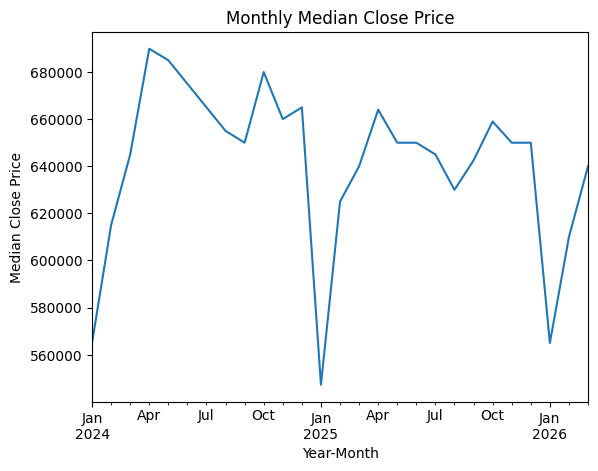

In [413]:
monthly_price = week6_sold.groupby("YrMo")["ClosePrice"].median()

monthly_price.plot()

plt.title("Monthly Median Close Price")
plt.xlabel("Year-Month")
plt.ylabel("Median Close Price")

plt.show()

The monthly median close price trend shows how pricing changes over time.

### 13. Visualize Monthly Median Days on Market

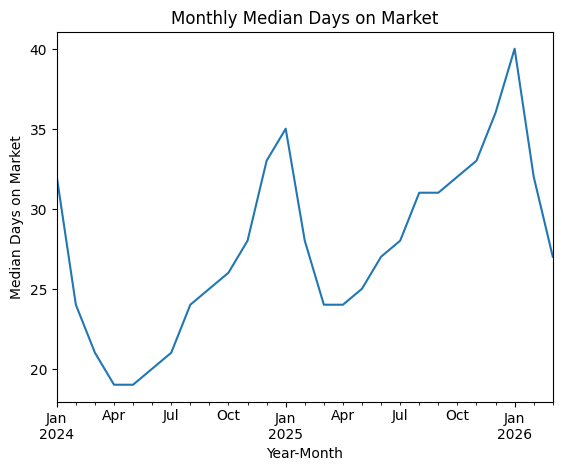

In [414]:
monthly_dom = week6_sold.groupby("YrMo")["DaysOnMarket"].median()

monthly_dom.plot()

plt.title("Monthly Median Days on Market")
plt.xlabel("Year-Month")
plt.ylabel("Median Days on Market")

plt.show()

The monthly Days on Market trend shows how market speed changes over time.

### 14. Save Week 6 Dataset

In [415]:
week6_sold.to_csv("week6_engineered_dataset.csv", index=False)

print("Saved week6_engineered_dataset.csv")

Saved week6_engineered_dataset.csv


The engineered Week 6 dataset was saved for future Tableau dashboard development and analysis.

### 15. Week 6 Summary

For Week 6, key market metrics were engineered, including PriceRatio, CloseToOriginalListRatio, PricePerSqft, DaysOnMarket, ListingToContractDays, ContractToCloseDays, Year, Month, and YrMo.

Segment summaries were created by PropertyType and CountyOrParish. Monthly trend visuals were also created for median close price and median Days on Market.

This completes the Week 6 feature engineering and market metrics deliverable.

# Week 7 - Outlier Detection and Final Dataset Preparation

The goal of Week 7 is to identify extreme values, flag potential outliers, compare distributions before and after filtering, and create a final analysis-ready dataset.

### 1. Create Working Copies

In [416]:
week7_full = week6_sold.copy()
week7_clean = week6_sold.copy()

print("Rows before outlier analysis:", len(week7_full))

Rows before outlier analysis: 546667


Two datasets were created. The full dataset retains all records and outlier flags, while the clean dataset will be filtered for analysis.

### 2. Flag Invalid Values

In [417]:
week7_full["invalid_close_price_flag"] = (
    week7_full["ClosePrice"] <= 0
)

week7_full["invalid_living_area_flag"] = (
    week7_full["LivingArea"] <= 0
)

week7_full["invalid_days_on_market_flag"] = (
    week7_full["DaysOnMarket"] < 0
)

print("Invalid ClosePrice:", week7_full["invalid_close_price_flag"].sum())
print("Invalid LivingArea:", week7_full["invalid_living_area_flag"].sum())
print("Invalid DaysOnMarket:", week7_full["invalid_days_on_market_flag"].sum())

Invalid ClosePrice: 0
Invalid LivingArea: 0
Invalid DaysOnMarket: 0


Records with impossible values were flagged before performing outlier analysis.

### 3. Define Outlier Variables

In [418]:
outlier_vars = [
    "ClosePrice",
    "LivingArea",
    "PricePerSqft",
    "DaysOnMarket"
]

### 4. Create IQR Outlier Flags

In [419]:
for col in outlier_vars:

    q1 = week7_full[col].quantile(0.25)
    q3 = week7_full[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    week7_full[f"{col}_outlier_flag"] = (
        (week7_full[col] < lower) |
        (week7_full[col] > upper)
    )

    print(f"\n{col}")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print(
        "Outliers:",
        week7_full[f"{col}_outlier_flag"].sum()
    )


ClosePrice
Lower Bound: -1124500.0
Upper Bound: 2367500.0
Outliers: 28956

LivingArea
Lower Bound: -257.5
Upper Bound: 3594.5
Outliers: 25421

PricePerSqft
Lower Bound: -590.0394101195017
Upper Bound: 1383.0091533180778
Outliers: 11437

DaysOnMarket
Lower Bound: -61.0
Upper Bound: 131.0
Outliers: 36775


### 5. Review Outlier Counts

Outlier counts were summarized to determine how much of the dataset would be affected by filtering.

In [420]:
outlier_summary = pd.DataFrame()

outlier_summary["Variable"] = outlier_vars

outlier_summary["OutlierCount"] = [
    week7_full[f"{col}_outlier_flag"].sum()
    for col in outlier_vars
]

outlier_summary["OutlierPercent"] = (
    outlier_summary["OutlierCount"] /
    len(week7_full) * 100
).round(2)

print(outlier_summary)

       Variable  OutlierCount  OutlierPercent
0    ClosePrice         28956            5.30
1    LivingArea         25421            4.65
2  PricePerSqft         11437            2.09
3  DaysOnMarket         36775            6.73


### 6. Histograms Before Filtering

Histograms were created before filtering to visualize the original distributions and identify the impact of extreme observations.

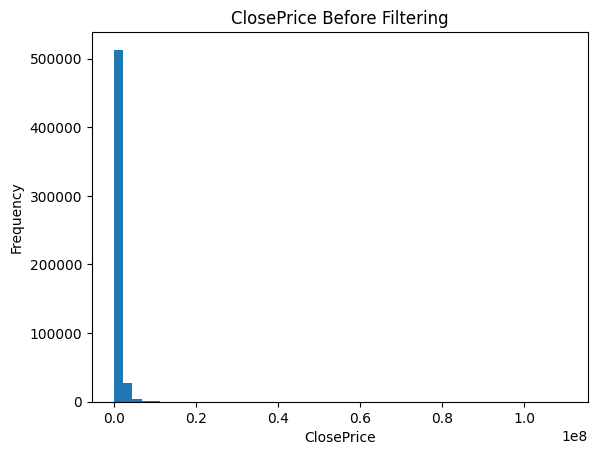

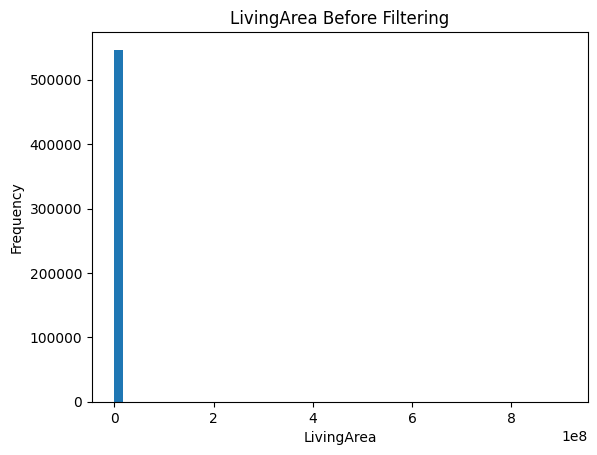

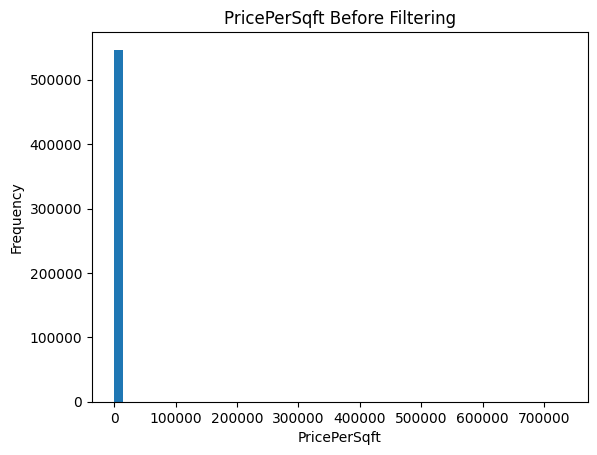

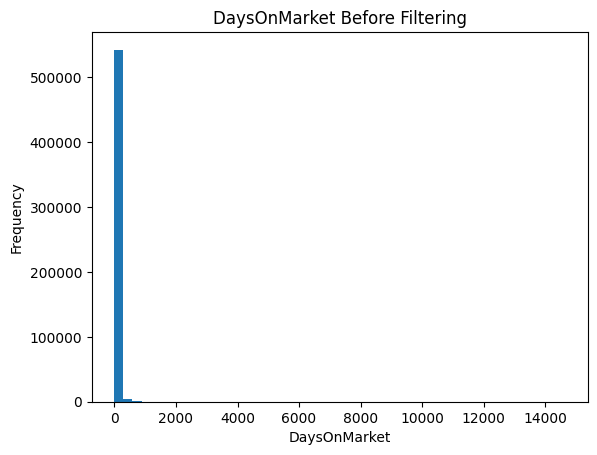

In [421]:
for col in outlier_vars:

    week7_full[col].dropna().plot.hist(
        bins=50
    )

    plt.title(f"{col} Before Filtering")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

### 7. Boxplots Before Filtering

Boxplots were created before filtering to visualize the presence of extreme values and potential outliers.

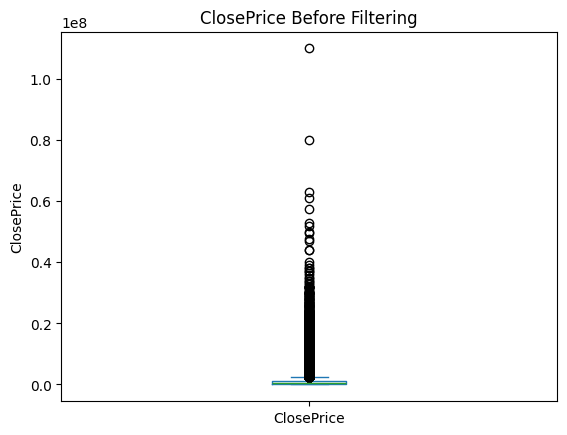

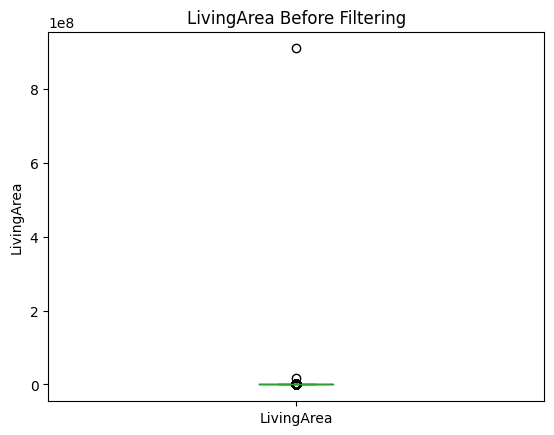

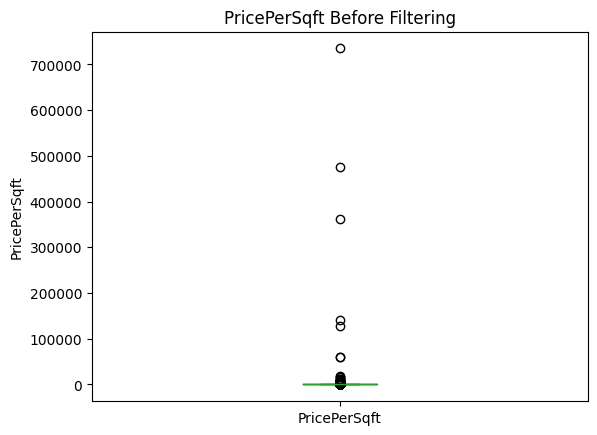

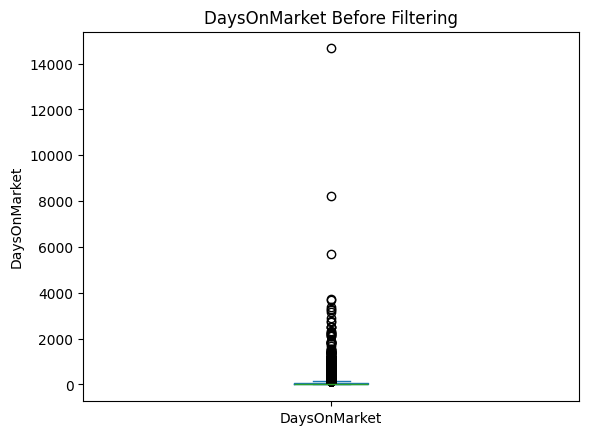

In [422]:
for col in outlier_vars:

    week7_full[col].dropna().plot.box()

    plt.title(f"{col} Before Filtering")
    plt.ylabel(col)

    plt.show()

### 8. Create Clean Dataset

Records flagged as outliers were removed from the clean dataset.

In [423]:
week7_clean = week7_full.copy()

for col in outlier_vars:

    week7_clean = week7_clean[
        week7_clean[f"{col}_outlier_flag"] == False
    ]

print("Rows before filtering:", len(week7_full))
print("Rows after filtering:", len(week7_clean))
print(
    "Rows removed:",
    len(week7_full) - len(week7_clean)
)

Rows before filtering: 546667
Rows after filtering: 468963
Rows removed: 77704


### 9. Histograms After Filtering

Histograms were created after filtering to compare distributions before and after outlier removal.

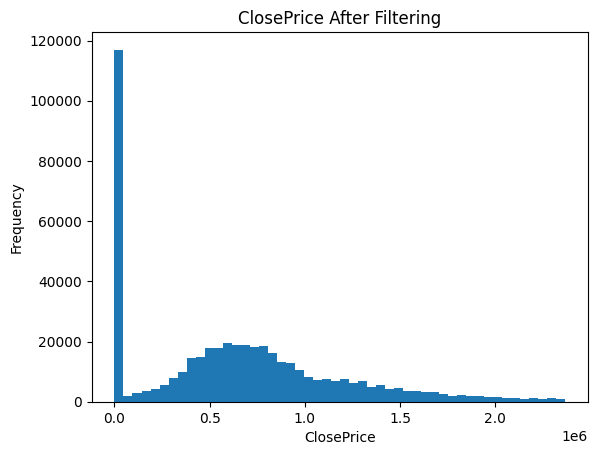

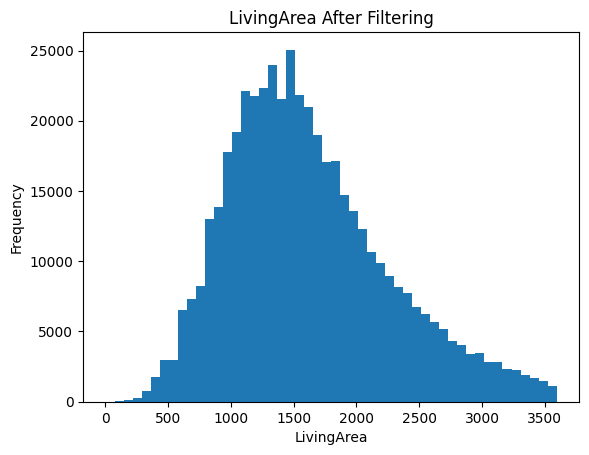

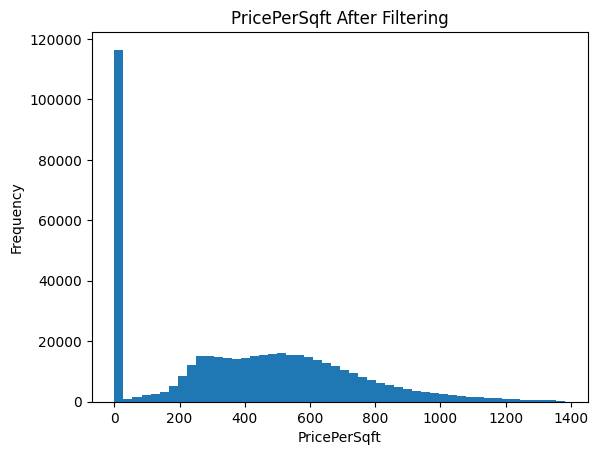

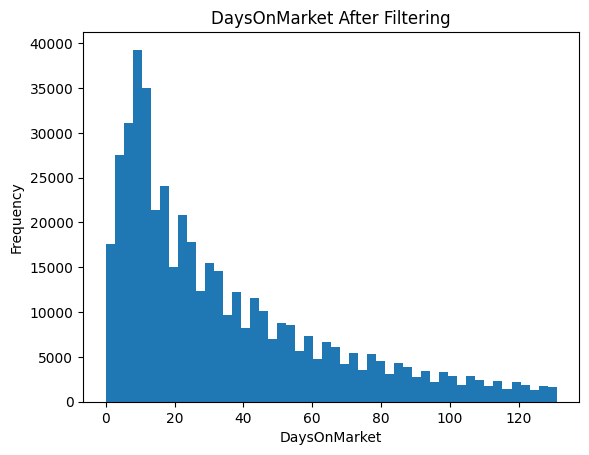

In [424]:
for col in outlier_vars:

    week7_clean[col].dropna().plot.hist(
        bins=50
    )

    plt.title(f"{col} After Filtering")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

### 10. Boxplots After Filtering

Boxplots were created after filtering to confirm that extreme observations no longer dominate the distributions.

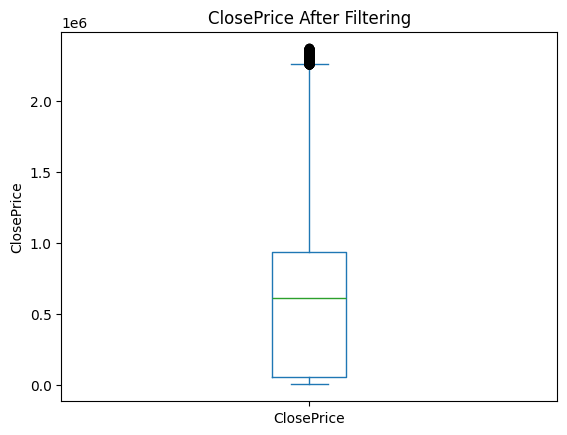

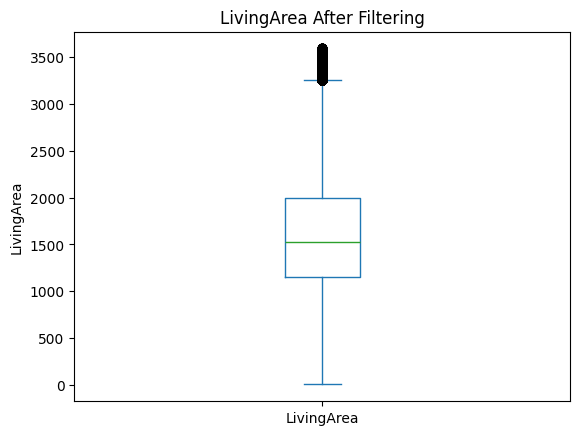

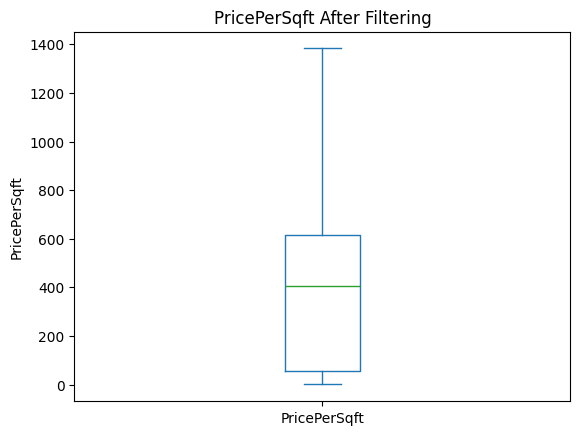

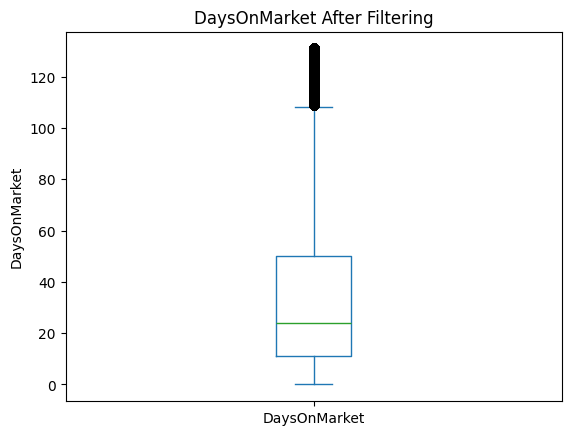

In [425]:
for col in outlier_vars:

    week7_clean[col].dropna().plot.box()

    plt.title(f"{col} After Filtering")
    plt.ylabel(col)

    plt.show()

### 11. Compare Median Values Before and After Filtering

Median values were compared before and after filtering to evaluate the impact of outlier removal.

                     Before          After
ClosePrice    645000.000000  610000.000000
LivingArea      1580.000000    1521.000000
PricePerSqft     417.933131     404.075896
DaysOnMarket      27.000000      24.000000


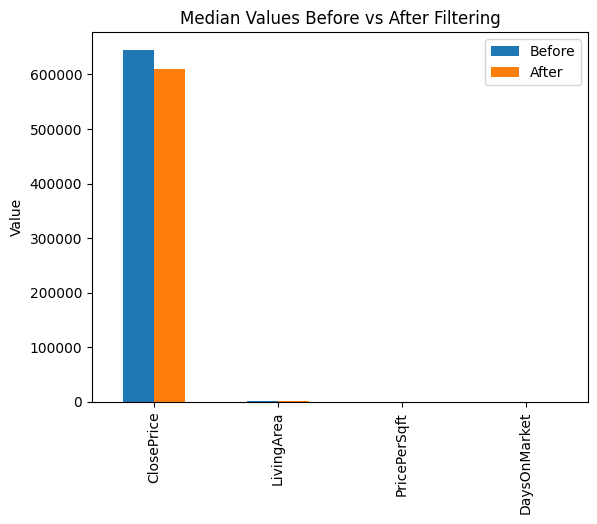

In [426]:
comparison = pd.DataFrame({
    "Before": week7_full[outlier_vars].median(),
    "After": week7_clean[outlier_vars].median()
})

print(comparison)

comparison.plot.bar()

plt.title("Median Values Before vs After Filtering")
plt.ylabel("Value")

plt.show()

### 12. Compare Summary Statistics

Summary statistics were compared before and after filtering to assess the impact of outlier removal.

In [427]:
before_stats = week7_full[outlier_vars].describe().T

after_stats = week7_clean[outlier_vars].describe().T

comparison_stats = pd.concat(
    [before_stats, after_stats],
    axis=1,
    keys=["Before", "After"]
)

print(comparison_stats)

                Before                                                        \
                 count           mean           std       min            25%   
ClosePrice    546667.0  837063.622326  1.151511e+06  1.900000  185000.000000   
LivingArea    546667.0    3505.855325  1.229763e+06  1.000000    1187.000000   
PricePerSqft  546667.0     447.358359  1.366843e+03  0.000002     149.853801   
DaysOnMarket  546667.0      46.155554  6.617330e+01  0.000000      11.000000   

                                                           After  \
                        50%           75%          max     count   
ClosePrice    645000.000000  1.058000e+06  110000000.0  468963.0   
LivingArea      1580.000000  2.150000e+03  909090909.0  468963.0   
PricePerSqft     417.933131  6.431159e+02     735000.0  468963.0   
DaysOnMarket      27.000000  5.900000e+01      14657.0  468963.0   

                                                                      \
                       mean           

### 13. Save Full Flagged Dataset

The full dataset containing all records and outlier flags was saved for reference.

In [428]:
week7_full.to_csv(
    "week7_full_flagged_dataset.csv",
    index=False
)

print("Saved week7_full_flagged_dataset.csv")

Saved week7_full_flagged_dataset.csv


### 14. Save Clean Dataset

The final filtered dataset was saved for future analysis and dashboard development.

In [429]:
week7_clean.to_csv(
    "week7_clean_filtered_dataset.csv",
    index=False
)

print("Saved week7_clean_filtered_dataset.csv")

Saved week7_clean_filtered_dataset.csv


### 15. Week 7 Summary

For Week 7, outliers were identified using the IQR method. Records were flagged, reviewed, and summarized before creating a filtered dataset.

Histograms and boxplots were used to compare distributions before and after filtering. Summary statistics and median values were also compared to evaluate the impact of outlier removal.

Both the full flagged dataset and the final filtered dataset were saved for future analysis and dashboard development.

# Week 8 - Tableau Dataset Export

Prepare a final analysis-ready dataset for Tableau dashboard development.

In [430]:
print("ClosePrice in sold:", "ClosePrice" in sold.columns)
print("ClosePrice in listed:", "ClosePrice" in listed.columns)
print("ClosePrice in residential:", "ClosePrice" in residential.columns)

ClosePrice in sold: True
ClosePrice in listed: False
ClosePrice in residential: True


In [431]:
# =========================
# Tableau Export Dataset
# =========================

tableau_data = residential.copy()

tableau_data["year_month"] = tableau_data["year_month"].dt.to_timestamp()

tableau_columns = [
    "ListingKey",
    "City",
    "PostalCode",
    "PropertyType",
    "PropertySubType",
    "CountyOrParish",
    "MLSAreaMajor",
    "ListOfficeName",
    "BuyerOfficeName",
    "ListAgentFullName",
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice",
    "ListingContractDate",
    "PurchaseContractDate",
    "CloseDate",
    "ContractStatusChangeDate",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "Latitude",
    "Longitude",
    "UnparsedAddress",
    "year_month"
]

tableau_data = tableau_data[
    [col for col in tableau_columns if col in tableau_data.columns]
]

print("TABLEAU EXPORT SHAPE:")
print(tableau_data.shape)

print("\nTABLEAU EXPORT COLUMNS:")
print(tableau_data.columns)

tableau_data.to_csv(
    "tableau_market_dataset.csv",
    index=False
)

print("\nSaved: tableau_market_dataset.csv")

TABLEAU EXPORT SHAPE:
(839073, 24)

TABLEAU EXPORT COLUMNS:
Index(['ListingKey', 'City', 'PostalCode', 'PropertyType', 'PropertySubType',
       'CountyOrParish', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListPrice', 'OriginalListPrice', 'ClosePrice',
       'ListingContractDate', 'PurchaseContractDate', 'CloseDate',
       'ContractStatusChangeDate', 'LivingArea', 'BedroomsTotal',
       'BathroomsTotalInteger', 'Latitude', 'Longitude', 'UnparsedAddress',
       'year_month'],
      dtype='object')

Saved: tableau_market_dataset.csv


In [433]:
required_competitive_fields = [
    "PropertySubType",
    "CountyOrParish",
    "ListOfficeName",
    "ListAgentFullName",
    "Latitude",
    "Longitude"
]

for col in required_competitive_fields:
    print(col, col in tableau_data.columns)

PropertySubType True
CountyOrParish True
ListOfficeName True
ListAgentFullName True
Latitude True
Longitude True
